In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 870.5/870.5 kB 15.1 MB/s eta 0:00:00


In [36]:
import torch
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim

In [13]:
def load_model(model_path, model_type):
    """ Load YOLO models based on the model type (plate/segmentation). """
    if model_type == 'plate' or model_type == 'segmentation':
        return YOLO(model_path)  # Make sure YOLO is properly imported
    else:
        raise ValueError("Unknown model type.")

In [38]:
def load_character_recognition_model(model_path):
    """ Load the character recognition model from the given path. """
    model = torch.load(model_path)
    if isinstance(model, torch.nn.Module):
        model.eval()  # Set model to evaluation mode if it's a valid torch model
    return model

In [15]:
def preprocess_character_image(char_img, input_size=(64, 64)):
    """ Resize and normalize the character image for the character recognition model. """
    char_img_resized = cv2.resize(char_img, input_size)  # Resize the image
    char_img_tensor = torch.from_numpy(char_img_resized).float() / 255.0  # Normalize the image
    char_img_tensor = char_img_tensor.unsqueeze(0)  # Add batch dimension (1, H, W)
    char_img_tensor = char_img_tensor.permute(0, 3, 1, 2)  # Convert to (batch_size, channels, height, width)
    return char_img_tensor

In [16]:
def recognize_characters(character_images, character_model):
    """ Recognize characters in segmented images using the character recognition model. """
    recognized_plate = ""
    for char_img in character_images:
        char_img_tensor = preprocess_character_image(char_img)
        char_prediction = character_model(char_img_tensor)
        _, predicted_char = torch.max(char_prediction, 1)
        recognized_plate += str(predicted_char.item())
    return recognized_plate

In [17]:
def preprocess_for_character_recognition(image, target_size=(64, 64)):
    """
    Preprocess the segmented character image to match the input size expected by the character recognition model.
    """
    image_resized = cv2.resize(image, target_size)
    image_normalized = image_resized / 255.0
    image_reshaped = np.expand_dims(image_normalized, axis=0)
    return image_reshaped

In [18]:
def show_image(image, title="Image", bbox=None):
    """ Display the image with optional bounding boxes. """
    plt.figure(figsize=(8, 6))
    if bbox is not None:
        for box in bbox:
            cv2.rectangle(image, (box[0], box[1]), (box[2], box[3]), (255, 0, 0), 2)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

In [27]:
def process_image(image_path, model_path_plate, model_path_segmentation, model_path_character, class_names):
    """ Complete process from plate detection to character recognition with visualization. """
    # Load models
    plate_model = load_model(model_path_plate, model_type='plate')
    segmentation_model = load_model(model_path_segmentation, model_type='segmentation')
    character_model = load_character_recognition_model(model_path_character)

    # Step 1: Detect the number plate in the image
    image = cv2.imread(image_path)
    plate_results = plate_model(image)

    # Visualize the detected plate
    if len(plate_results) > 0:
        bbox = plate_results[0].boxes.xyxy[0].cpu().numpy().astype(int)
        plate_image = image[bbox[1]:bbox[3], bbox[0]:bbox[2]]  # Crop the plate region
        show_image(image, title="Detected Plate", bbox=[bbox])  # Show image with the detected plate

        # Step 2: Segment characters from the plate
        segmentation_results = segmentation_model(plate_image)
        segmented_characters = segmentation_results[0].boxes.xyxy.cpu().numpy().astype(int)

        # Sort the bounding boxes from left to right (based on x-coordinate)
        segmented_characters = sorted(segmented_characters, key=lambda x: x[0])  # Sort by x (left-most point)

        show_image(plate_image, title="Segmented Characters", bbox=segmented_characters)  # Show segmented characters

        recognized_plate = ''

        # Step 3: For each segmented character, perform recognition
        for i, char_bbox in enumerate(segmented_characters):
            char_image = plate_image[char_bbox[1]:char_bbox[3], char_bbox[0]:char_bbox[2]]
            preprocessed_char_image = preprocess_for_character_recognition(char_image)

            # Visualize each character
            show_image(char_image, title=f"Character {i+1}")

            # Perform inference on the character recognition model
            char_prediction = character_model(preprocessed_char_image)  # TensorFlow model prediction

            # Convert the prediction (class index) into an actual character (using class_names)
            predicted_char_index = np.argmax(char_prediction, axis=-1)[0]
            recognized_plate += class_names[predicted_char_index]

        return recognized_plate

    return None


In [28]:
class_names = [
    "क", "को", "ख", "ग", "च", "ज", "झ", "ञ", "डि", "त", "ना", "प", "प्र", "ब",
    "बा", "भे", "म", "मे", "य", "लु", "सी", "सु", "से", "ह", "०", "१", "२", "३",
    "४", "५", "६", "७", "८", "९"
]

In [29]:
model_path_plate = '/content/ModelPlate.pt'
model_path_segmentation = '/content/ModelSegment.pt'
model_path_character = '/content/ModelCharacter.pth'


0: 416x640 1 number_plate, 416.7ms
Speed: 3.2ms preprocess, 416.7ms inference, 1.2ms postprocess per image at shape (1, 3, 416, 640)


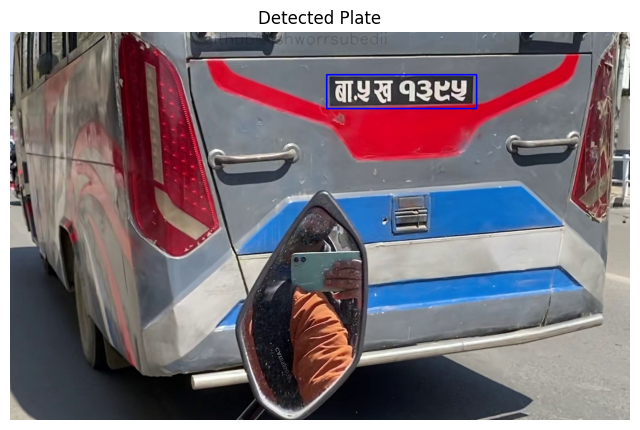


0: 160x640 7 plate_characterss, 327.2ms
Speed: 1.5ms preprocess, 327.2ms inference, 7.2ms postprocess per image at shape (1, 3, 160, 640)


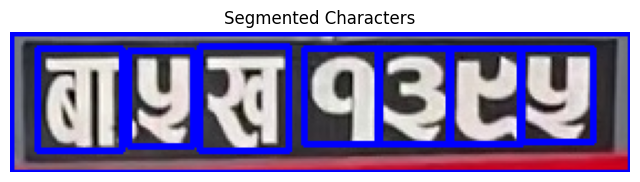

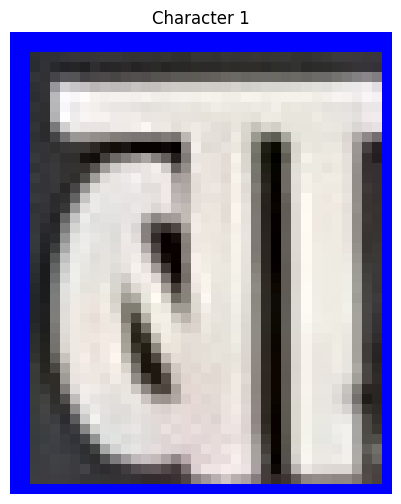

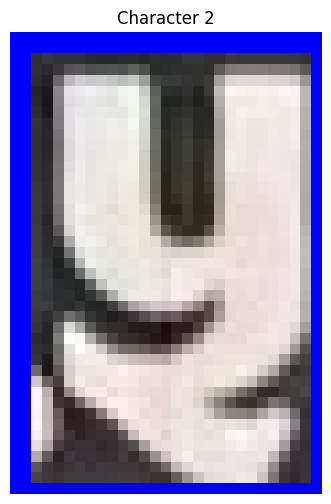

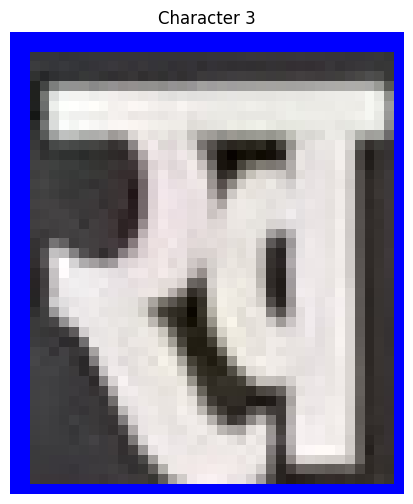

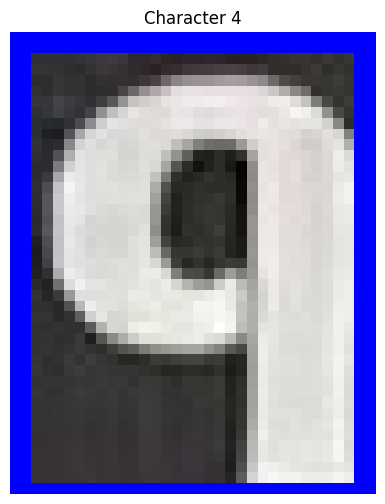

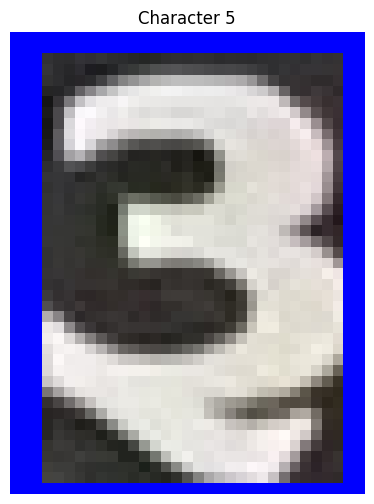

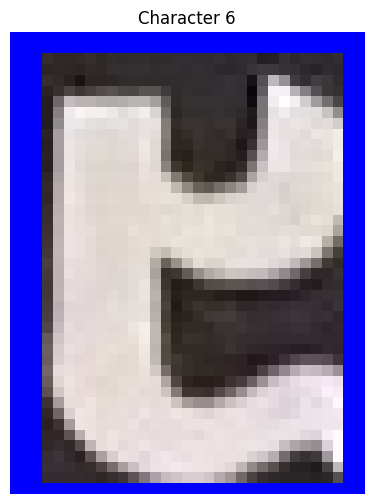

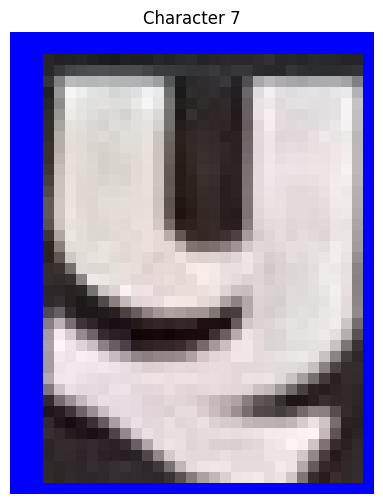

Recognized License Plate: बा५ख१३९५


In [30]:
image_path = '/content/2024-03-08_34_0.jpg'

# Process the image and print the recognized plate
recognized_plate = process_image(image_path, model_path_plate, model_path_segmentation, model_path_character, class_names)
print(f"Recognized License Plate: {recognized_plate}")